Imports and Settings

In [637]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [638]:
from copy import deepcopy
from enum import Enum

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import torch
from IPython.display import HTML, Video
from matplotlib.animation import FFMpegWriter, FuncAnimation
from pydmd import BOPDMD, DMD, HAVOK, HankelDMD
from pydmd.plotter import plot_eigs, plot_summary
from pydmd.preprocessing import hankel_preprocessing
from torch.nn import MSELoss
from torch.optim import SGD, Adam
from torch.utils.data import DataLoader
from torchinfo import summary
from torchnmf.nmf import NMF

from algo.embedding import hankel, make_hankel_matrix
from algo.lda import lda
from algo.mean_classifier import mean_classifier
from data import (
    GaussianDataset,
    LinearGaussianDataset,
    RectangularDataset,
    SpiralDataset,
    YinYangDataset,
)
from models.perceptron import MLP, HiddenLayerModel, SingleNeuronModel, init_weights
from visualization.boundary import extract_layer_weights, plot_decision_boundary_movie

In [639]:
# Make sure you have the correct matplotlib backend
%matplotlib inline

In [640]:
torch.set_printoptions(linewidth=100, sci_mode=True)
np.set_printoptions(linewidth=100)

Control Panel

In [641]:
class DatasetProblem(Enum):
    RECTANGULAR = 1
    SPIRAL = 2
    LINEAR = 3
    GAUSSSIAN = 4
    YINYANG = 5


class ModelClass(Enum):
    SingleNeuron = 1
    HiddenLayer = 2
    MLP = 3

In [642]:
# DATASET
PROBLEM = DatasetProblem.SPIRAL
NOISE = 0.2  # only valid for SpiralDataset
NUM_SAMPLES = 1_000
NUM_GAUSS_FEATURES = 0

# VISUALIZATION
FIGSIZE = (20, 5)

Dataset

In [643]:
# Build dataset
if PROBLEM == DatasetProblem.RECTANGULAR:
    dataset = RectangularDataset(
        num_samples=NUM_SAMPLES, num_extra_features=NUM_GAUSS_FEATURES
    )
elif PROBLEM == DatasetProblem.SPIRAL:
    dataset = SpiralDataset(
        num_samples=NUM_SAMPLES, num_extra_features=NUM_GAUSS_FEATURES, noise=NOISE
    )
elif PROBLEM == DatasetProblem.LINEAR:
    dataset = LinearGaussianDataset(
        num_samples=NUM_SAMPLES, num_extra_features=NUM_GAUSS_FEATURES
    )
elif PROBLEM == DatasetProblem.GAUSSSIAN:
    dataset = GaussianDataset(
        num_samples=NUM_SAMPLES, num_extra_features=NUM_GAUSS_FEATURES
    )
elif PROBLEM == DatasetProblem.YINYANG:
    dataset = YinYangDataset(size=NUM_SAMPLES)
else:
    raise NotImplementedError()

In [644]:
# Extract data to numpy for visualization
features = dataset.features.numpy()
labels = dataset.labels.numpy()

Visualize Dataset

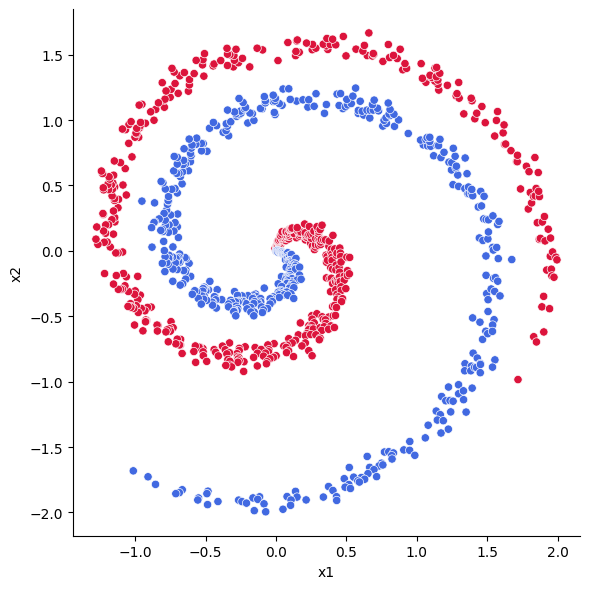

In [645]:
# Grab only first two columns
df = pd.DataFrame(features[:, :2], columns=["x1", "x2"])
df["label"] = pd.Series(labels.squeeze(1)).apply(
    lambda x: "crimson" if x == -1 else "royalblue"
)

# Create the plot
plt.figure(figsize=(6, 6))  # Adjust size as needed

sns.scatterplot(
    x="x1", y="x2", hue="label", data=df, palette=["crimson", "royalblue"], legend=False
)
# Remove spines (the box around the plot)
sns.despine(left=False, bottom=False)

# Adjust plot margins (reduce padding)
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)

# Show the plot
plt.tight_layout()
plt.show()

Mean Classifier

In [646]:
mean_vector = mean_classifier(dataset.features, dataset.labels, x=[-5, 5])
# mean_vector = mean_classifier(dataset.features, dataset.labels, x=[0.2, 0.8])
mean_vector

([-5, 5], [-1.9171485900878906, 1.9144716262817383])

In [647]:
lda_vector = lda(dataset.features, dataset.labels, x=[-3, 3])
# lda_vector = lda(dataset.features, dataset.labels, x=[0.2, 0.8])
lda_vector

[ 0.19163715 -0.460445  ] [-0.00255642]


([-3, 3], [array([-1.25415165]), array([1.24304751])])

Model Setup

In [685]:
# MODEL
MODEL_CLASS = ModelClass.MLP
HIDDEN_NEURONS = [24]  # only valid for HiddenLayerModel

# MODEL TRAINING
BATCH_SIZE = 512
NUM_EPOCHS = 10_000
LEARNING_RATE = 1e-2

In [686]:
if MODEL_CLASS == ModelClass.SingleNeuron:
    model = SingleNeuronModel(in_features=features.shape[-1])
elif MODEL_CLASS == ModelClass.HiddenLayer:
    model = HiddenLayerModel(neurons=HIDDEN_NEURONS[0], in_features=features.shape[-1])
elif MODEL_CLASS == ModelClass.MLP:
    model = MLP(config=HIDDEN_NEURONS, in_features=features.shape[-1])
else:
    raise NotImplementedError()

model.apply(init_weights)

MLP(
  (features): Sequential(
    (0): Linear(in_features=2, out_features=24, bias=False)
    (1): Tanh()
    (2): Linear(in_features=24, out_features=1, bias=False)
    (3): Tanh()
  )
)

Train Model

In [687]:
dataloader = DataLoader(dataset=dataset, shuffle=True, batch_size=BATCH_SIZE)

In [688]:
criterion = MSELoss()
optimizer = SGD(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

In [689]:
loss_vector = []
state_dicts = []

SAVE_FREQ = 1
PRINT_FREQ = 50

In [690]:
model.to(device="cuda:0")
model.train()
for epoch in range(NUM_EPOCHS):
    total_loss = 0

    for batch in dataloader:
        optimizer.zero_grad()
        input, label = batch
        input = input.to(device="cuda:0")
        label = label.to(device="cuda:0")

        output = model(input)

        loss = criterion(output, label)
        loss.backward()
        optimizer.step()

        total_loss += loss

    total_loss /= len(dataloader)

    if epoch == 0 or (epoch + 1) % SAVE_FREQ == 0:
        loss_vector.append(total_loss.detach().cpu())
        state_dicts.append(deepcopy(model.state_dict()))

    if epoch == 0 or (epoch + 1) % PRINT_FREQ == 0:
        print(f"Epoch {epoch}. Loss: {total_loss}")

Epoch 0. Loss: 0.996688723564148
Epoch 49. Loss: 0.9642513990402222


Epoch 99. Loss: 0.9625256657600403
Epoch 149. Loss: 0.961477518081665
Epoch 199. Loss: 0.9607037305831909
Epoch 249. Loss: 0.9594040513038635
Epoch 299. Loss: 0.9586277008056641
Epoch 349. Loss: 0.9568284749984741
Epoch 399. Loss: 0.9556601643562317
Epoch 449. Loss: 0.9541728496551514
Epoch 499. Loss: 0.952215313911438
Epoch 549. Loss: 0.950883150100708
Epoch 599. Loss: 0.9487707018852234
Epoch 649. Loss: 0.9466534852981567
Epoch 699. Loss: 0.944587230682373
Epoch 749. Loss: 0.9416834115982056
Epoch 799. Loss: 0.9385652542114258
Epoch 849. Loss: 0.9353516101837158
Epoch 899. Loss: 0.9323438405990601
Epoch 949. Loss: 0.9282702207565308
Epoch 999. Loss: 0.9238353967666626
Epoch 1049. Loss: 0.9199411273002625
Epoch 1099. Loss: 0.9150065183639526
Epoch 1149. Loss: 0.9103906154632568
Epoch 1199. Loss: 0.9055705070495605
Epoch 1249. Loss: 0.9013014435768127
Epoch 1299. Loss: 0.8966417908668518
Epoch 1349. Loss: 0.8931102752685547
Epoch 1399. Loss: 0.8891143798828125
Epoch 1449. Loss: 0.88507

Space Time Map

In [691]:
LAYER_NUM = 0

In [692]:
weights_0 = extract_layer_weights(
    model=model, state_dicts=state_dicts, layer_num=LAYER_NUM
).T
weights_0.shape

torch.Size([48, 10000])

In [693]:
weights_0 -= torch.min(weights_0)

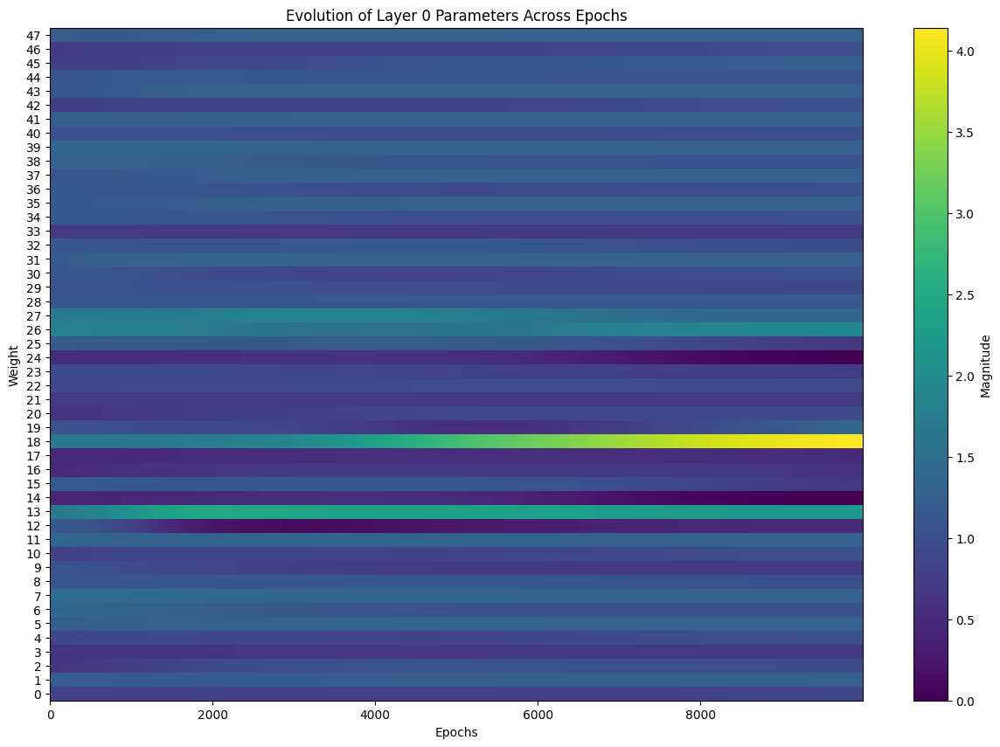

In [694]:
# Create x and y grids
tgrid = np.arange(NUM_EPOCHS)  # Epochs from 0 to 199
ygrid = np.arange(weights_0.shape[0])  # Discrete y-values for variables

# Create the plot
plt.figure(figsize=(15, 10))  # Adjust figure size as needed
plt.pcolor(tgrid, ygrid, weights_0, cmap="viridis")  # Use pcolor for filled contours
plt.title(f"Evolution of Layer {LAYER_NUM} Parameters Across Epochs")
plt.xlabel("Epochs")
plt.ylabel("Weight")
plt.yticks(
    np.arange(ygrid.size), labels=np.arange(ygrid.size)
)  # Show all weight indices
plt.colorbar(label="Magnitude")  # Add colorbar to interpret values

plt.show()

Decision Boundary

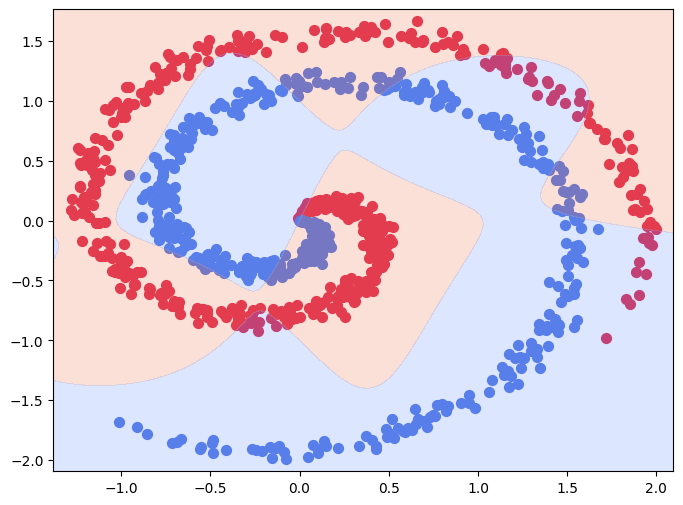

In [695]:
# Set the animation embed limit if needed
matplotlib.rcParams["animation.embed_limit"] = 2**128

# Assuming plot_decision_boundary_movie is a function that creates the animation
ani = plot_decision_boundary_movie(
    model, state_dicts[::100], features, labels.squeeze(1)
)
HTML(ani.to_jshtml())

In [765]:
RANK = 4
nmf_model = NMF(weights_0.t().shape, rank=RANK)
nmf_model.fit(weights_0.t(), max_iter=500)

350

In [766]:
plotH = nmf_model.H.cpu().detach().t().numpy()
print(plotH.shape)
plotW = nmf_model.W.cpu().detach().t().numpy()
print(plotW.shape)

(4, 10000)
(4, 48)


In [767]:
# Assuming `plotH` and `plotW` are numpy arrays

# --- Bar Chart for plotW ---

# Dynamically Determine Shape
num_bar_groups, num_bars_per_group = plotW.shape[0], plotW.shape[1]

# Create DataFrame for Bar Charts
df_bar = pd.DataFrame({"X": np.arange(num_bars_per_group)})
for i in range(num_bar_groups):
    df_bar[f"w[{i}]"] = plotW[i]

# Create Bar Chart Figure
fig_bar = px.bar(
    df_bar,
    x="X",
    y=df_bar.columns[1:],
    barmode="group",
    title="Multiple W Bar Charts",
)
fig_bar.update_layout(
    xaxis_title="Index",
    yaxis_title="Value",
    legend_title="W Bars",
    template="plotly_white",
)


# --- Line Chart for plotH ---

# Assuming RANK is defined elsewhere
num_lines = RANK
x_values = np.arange(len(plotH[0]))

# Create DataFrame for Line Chart
df = pd.DataFrame({"X": x_values})
for i in range(num_lines):
    df[f"vh[{i}]"] = plotH[i]

# Create Line Chart Figure
fig = px.line(
    df,
    x="X",
    y=df.columns[1:],
    title="Multiple vh Plots",
)
fig.update_traces(mode="lines+markers")
fig.update_layout(
    xaxis_title="Index",
    yaxis_title="Value",
    legend_title="vh Lines",
    template="plotly_white",
)

# --- Display Both Plots ---
fig.show()
fig_bar.show()

In [768]:
INDEX = 0

x_values = np.arange(len(plotH[0]))

weights = np.expand_dims(plotW[:, INDEX], axis=0)
recreated = weights @ plotH

# Create DataFrame for Line Chart
df = pd.DataFrame({"X": x_values})
df["original"] = weights_0[INDEX]
df["recreated"] = recreated[0]

# Create Line Chart Figure
fig = px.line(
    df,
    x="X",
    y=df.columns[1:],
    title="Stuff",
)
fig.update_traces(mode="lines+markers")
fig.update_layout(
    xaxis_title="Index",
    yaxis_title="Value",
    legend_title="vh Lines",
    template="plotly_white",
)

# --- Display Both Plots ---
fig.show()

HAVOK-Style Analysis

In [812]:
embedded_matrix = hankel(weights_0[0, :].cuda(), delays=2500, lag=2)
print(f"Shape: {embedded_matrix.shape}")

Shape: torch.Size([2500, 5002])


In [813]:
RANK = 2
nmf_model = NMF(embedded_matrix.t().shape, rank=RANK)
nmf_model.fit(embedded_matrix.t(), max_iter=500)

70

In [814]:
plotH = nmf_model.H.cpu().detach().t().numpy()
plotH.shape

(2, 5002)

In [815]:
import plotly.express as px
import pandas as pd
import numpy as np

# Assuming `plot_vh` is a 2D array or list of lists
num_lines = RANK  # Plot the first 10 lines
x_values = np.arange(len(plotH[0]))  # Array of indices for x-axis

# Create DataFrame for Plotly Express
df = pd.DataFrame({"X": x_values})
for i in range(num_lines):
    df[f"vh[{i}]"] = plotH[i]  # Add each line as a column

# Create the Plot
fig = px.line(
    df, x="X", y=df.columns[1:], title="Multiple vh Plots"
)  # Plot all columns except "X"

# Automatic Color Cycling
fig.update_traces(mode="lines+markers")  # Add markers for better visibility

# Optional Customization
fig.update_layout(
    xaxis_title="Index",
    yaxis_title="Value",  # Generalized y-axis title
    legend_title="vh Lines",
    template="plotly_white",
)

# Show the Plot
fig.show()

In [816]:
# import plotly.graph_objects as go

# # Assuming you have your Lorenz Attractor data in `plot_vh`
# fig = go.Figure(
#     data=[go.Scatter3d(x=plot_vh[0], y=plot_vh[1], z=plot_vh[2], mode="lines")]
# )

# # Update layout to adjust height
# fig.update_layout(
#     autosize=False,  # Disable autosizing
#     width=800,  # Set desired width (in pixels)
#     height=600,  # Set desired height (in pixels)
# )

# fig.show()